# Indicadores de régimen hidrológico
***

In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import cartopy.crs as ccrs
import cartopy.feature as cf
from pathlib import Path

from config import Config
from signatures import annual_runoff, baseflow_index, flashiness_index, slope_fdc #, flow_duration_curve
from plots import plot_timeseries_interactive

## Configuración

In [3]:
cfg = Config('../config.yml')

proj = ccrs.PlateCarree()

## Datos

### Estaciones

In [4]:
# capa de estaciones generado a partir del Anuario (estaf.csv)
stns = gpd.read_file(cfg.path_GIS / 'estaciones.shp').set_index('indroea')
stns.sort_index(axis=0, inplace=True)
stns.index = stns.index.astype(int)

print('Nº estaciones:\t{0}\nNº atributos:\t{1}'.format(*stns.shape))

Nº estaciones:	1200
Nº atributos:	31


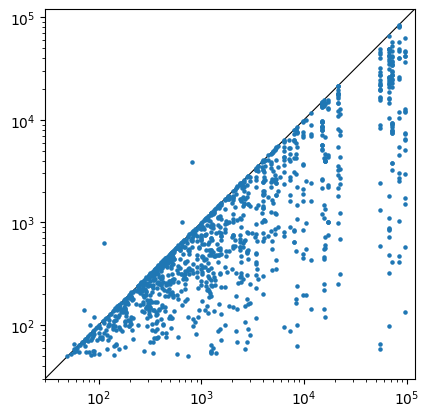

In [5]:
fig, ax = plt.subplots()
lims = [30, 1.2e5]
ax.scatter(stns.suprcnc, stns.suprest, s=5)
ax.plot(lims, lims, ls='-', lw=.8, c='k', zorder=0)
ax.set(
    xlim=lims,
    # xlabel='Cuenca total (km³)',
    ylim=lims,
    # ylabel='Cuenca receptora (km³)'
)
ax.set_aspect('equal')
ax.loglog();

In [6]:
# capa de estaciones descargadas del MITECO
estaciones = pd.read_csv(
    cfg.path_in / 'estaciones' / 'Situac 4_Rio.csv', 
    index_col='COD_HIDRO', 
    encoding='latin1', 
    sep=';',
    decimal=','
    )
estaciones = gpd.GeoDataFrame(
    data=estaciones,
    geometry=gpd.points_from_xy(
        estaciones.COORD_UTMX_H30_ETRS89, 
        estaciones.COORD_UTMY_H30_ETRS89, 
        crs='EPSG:25830'
        )
)
estaciones = estaciones.to_crs(epsg=4326)
# for col in ['CUENCA_TOTAL', 'CUENCA_RECEP']:
#     estaciones[col] = estaciones[col].str.replace({',': '.'}).astype(float)
estaciones.REGIMEN_RIO = estaciones.REGIMEN_RIO.str.lower()
estaciones.REGIMEN_RIO = estaciones.REGIMEN_RIO.replace({
    'muy modificado': 'alterado',
    '-': 'desconocido',
    np.nan: 'desconocido'
    })

print('Nº estaciones:\t{0}\nNº atributos:\t{1}'.format(*estaciones.shape))

Nº estaciones:	1491
Nº atributos:	46


### Caudal

In [7]:
# cargar series diarias de caudals preprocesadas
caudal = pd.read_parquet(cfg.path_out / 'caudal.parquet')
caudal.sort_index(axis=1, inplace=True)
caudal.columns = caudal.columns.astype(int)

# eliminar estaciones con datos erróneos de caudal
mask = caudal.mean(skipna=True) == 0
print(f'{mask.sum()} estaciones eliminadas porque el caudal es siempre 0')
caudal = caudal.loc[:, ~mask]

print('Nº estaciones:\t{1}\nNº días:\t{0}'.format(*caudal.shape))

4 estaciones eliminadas porque el caudal es siempre 0
Nº estaciones:	936
Nº días:	10958


In [8]:
ids = estaciones.index.intersection(caudal.columns)
estaciones = estaciones.loc[ids]
caudal = caudal[ids]

print(f'Nº estaciones:\t{len(ids)}')

Nº estaciones:	936


### Plot

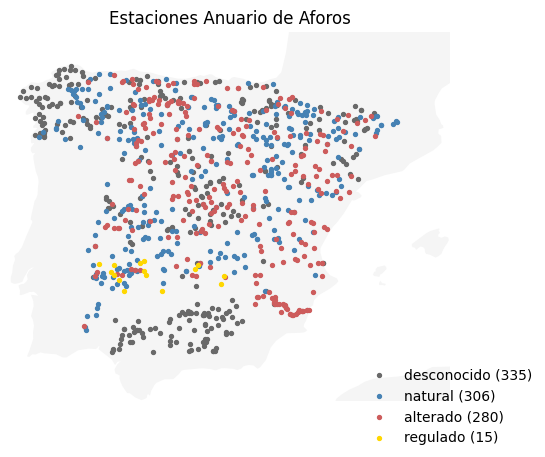

In [9]:
regimenes = {
    'desconocido': 'dimgrey',
    'natural': 'steelblue',
    'alterado': 'indianred',
    'regulado': 'gold',
}

fig, ax = plt.subplots(subplot_kw={'projection': proj})
ax.add_feature(cf.NaturalEarthFeature('physical', 'land', '50m', edgecolor=None, facecolor='whitesmoke'), zorder=0)

for regimen, c in regimenes.items():
    mask = estaciones.REGIMEN_RIO == regimen
    estaciones.loc[mask].plot(color=c, markersize=8, ax=ax, label=f'{regimen} ({mask.sum()})')
    
fig.legend(loc=4, frameon=False)
ax.set_title('Estaciones Anuario de Aforos')
ax.set_extent([-9.5, 3.5, 36, 44.5], crs=proj)
ax.axis('off');

## Índices hidrológicos

In [10]:
# correct catchment area fields
for col in ['CUENCA_TOTAL', 'CUENCA_RECEP']:
    estaciones[col] = estaciones[col].str.replace({',': '.'}).astype(float)

In [11]:
# Compute hydrological signatures
cols = ['FI', 'BFI', 'FDC', 'AR']
estaciones[cols] = np.nan
for stn in tqdm(caudal.columns):
    # extract discharge time series
    data = caudal[stn]
    start, end = data.first_valid_index(), data.last_valid_index()
    data = data[start:end]

    # compute indices
    fi = flashiness_index(data) # flashiness index
    fdc, slope = slope_fdc(data) # slope of the flow duration curve
    _, bfi = baseflow_index(data) # baseflow index
    ar = annual_runoff(data, area=stns.loc[stn, 'suprest']) # annual runoff

    # save
    estaciones.loc[stn, cols] = [fi, bfi, slope, ar]

  0%|          | 0/936 [00:00<?, ?it/s]

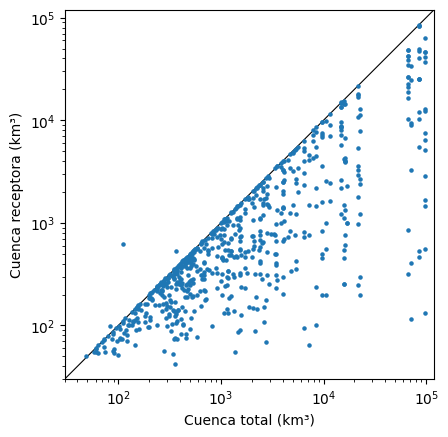

In [12]:
fig, ax = plt.subplots()
lims = [30, 1.2e5]
ax.scatter(estaciones.CUENCA_TOTAL, estaciones.CUENCA_RECEP, s=5)
ax.plot(lims, lims, ls='-', lw=.8, c='k', zorder=0)
ax.set(
    xlim=lims,
    xlabel='Cuenca total (km³)',
    ylim=lims,
    ylabel='Cuenca receptora (km³)'
)
ax.set_aspect('equal')
ax.loglog();

In [13]:
estaciones[cols].describe()

,FI,BFI,FDC,AR
count,936.000000,936.000000,936.000000,936.000000
mean,0.233698,0.712144,2.031968,347.897971
std,0.146727,0.112057,2.989059,415.386898
min,0.017296,0.300836,0.000000,0.291751
25%,0.130264,0.644521,0.852157,52.397205
50%,0.197519,0.727573,1.309109,155.019394
75%,0.297105,0.791433,1.802671,539.270452
max,0.949956,0.943847,19.211462,2899.873840


In [15]:
path_plot = Path('./plots')

cuenca = 'CANTABRICO'
path = path_plot/ cuenca
path.mkdir(exist_ok=True)
for stn in stns[stns.cuenca.str.upper() == cuenca].index:
    if stn not in caudal:
        continue
    ts = caudal[stn]
    ts = ts.loc[ts.first_valid_index():ts.last_valid_index()]
    title = '{0} - {1} ({2})'.format(stn, *estaciones.loc[stn, ['NOM_ANUARIO', 'SISTEMA_EXPLO']])
    regimen = estaciones.loc[stn, 'REGIMEN_RIO']
    plot_timeseries_interactive(
        ts, 
        area=stns.loc[stn, 'suprest'],
        title=title,
        regime=regimen,
        c=regimenes[regimen],
        save=path / f'{stn}.html'
)

In [41]:
import os

In [48]:
ids = [int(file.split('.')[0]) for file in files]
df = stns.loc[ids].copy()
df['link'] = ''
path = '/mnt/c/Datasets/CAMELS-ES/GIS/CANTABRICO'
for id in stns.index:
    df.loc[id, 'link'] = f'file:///C:/Datasets/CAMELS-ES/GIS/CANTABRICO/hydrograph/{id}.html'
df.to_file(f'{path}/estaciones.shp')

In [ ]:
files

['1080.html',
 '1100.html',
 '1103.html',
 '1105.html',
 '1106.html',
 '1109.html',
 '1141.html',
 '1163.html',
 '1164.html',
 '1175.html',
 '1186.html',
 '1196.html',
 '1207.html',
 '1215.html',
 '1216.html',
 '1217.html',
 '1237.html',
 '1262.html',
 '1264.html',
 '1265.html',
 '1268.html',
 '1274.html',
 '1276.html',
 '1285.html',
 '1293.html',
 '1294.html',
 '1295.html',
 '1297.html',
 '1302.html',
 '1303.html',
 '1305.html',
 '1335.html',
 '1339.html',
 '1342.html',
 '1343.html',
 '1344.html',
 '1353.html',
 '1358.html',
 '1359.html',
 '1363.html',
 '1365.html',
 '1369.html',
 '1375.html',
 '1378.html',
 '1395.html',
 '1398.html',
 '1402.html',
 '1404.html',
 '1414.html',
 '1424.html',
 '1425.html',
 '1426.html',
 '1427.html',
 '1429.html',
 '1937.html']

In [22]:
file.stem

'1207'

In [27]:
# 1. Setup paths (Change this to your actual folder)
index_path = path / "index.html"
files = sorted([f.name for f in path.glob("*.html") if f.name != "index.html"])

# 2. Start building the HTML content
html_content = """
<!DOCTYPE html>
<html>
<head>
    <title>Hydrology Station Gallery</title>
    <style>
        body { font-family: sans-serif; background-color: #f4f4f9; padding: 20px; }
        .grid { display: grid; grid-template-columns: repeat(auto-fill, minmax(200px, 1fr)); gap: 15px; }
        .card { 
            background: white; border: 1px solid #ddd; padding: 15px; 
            text-align: center; border-radius: 8px; transition: 0.3s;
            text-decoration: none; color: #333; display: block;
        }
        .card:hover { border-color: steelblue; box-shadow: 0 4px 8px rgba(0,0,0,0.1); color: steelblue; }
        h1 { color: #333; }
    </style>
</head>
<body>
    <h1>Study Area: Hydrograph Gallery</h1>
    <div class="grid">
"""

# 3. Add each file to the grid
for file_name in files:
    # We use the filename as both the Link (href) and the Display Name
    station_name = file_name.split('.')[0]
    html_content += f'<a class="card" href="{file_name}" target="_blank">{station_name}</a>\n'

# 4. Close tags and save
html_content += """
    </div>
</body>
</html>
"""

with open(path / "index.html", "w", encoding="utf-8") as f:
    f.write(html_content)

print(f"Done! Double-click this file to browse: {path / 'index.html'}")

Done! Double-click this file to browse: plots/CANTABRICO/index.html


In [ ]:

files = [file for file in path.glob('*.html') if file != index_path]
with open(index_path, "w") as f:
    f.write("<html><body><h1>Station Gallery</h1><ul>")
    for file in files:
        f.write(f"<li><a href='{file.name}' target='_blank'>{file}</a></li>")
    f.write("</ul></body></html>")

In [25]:
file.name

'1207.html'

In [ ]:
# for stn in estaciones[estaciones.FDC.isnull()].index:
stn = 1303
ts = caudal[stn]
ts = ts.loc[ts.first_valid_index():ts.last_valid_index()]
title = '{0} - {1} ({2})'.format(stn, *estaciones.loc[stn, ['NOM_ANUARIO', 'SISTEMA_EXPLO']])
regimen = estaciones.loc[stn, 'REGIMEN_RIO']
plot_timeseries_interactive(
    ts, 
    area=stns.loc[stn, 'suprest'],
    title=title,
    regime=regimen,
    c=regimenes[regimen]
    # save=path_plot / f'{stn}.html'
)

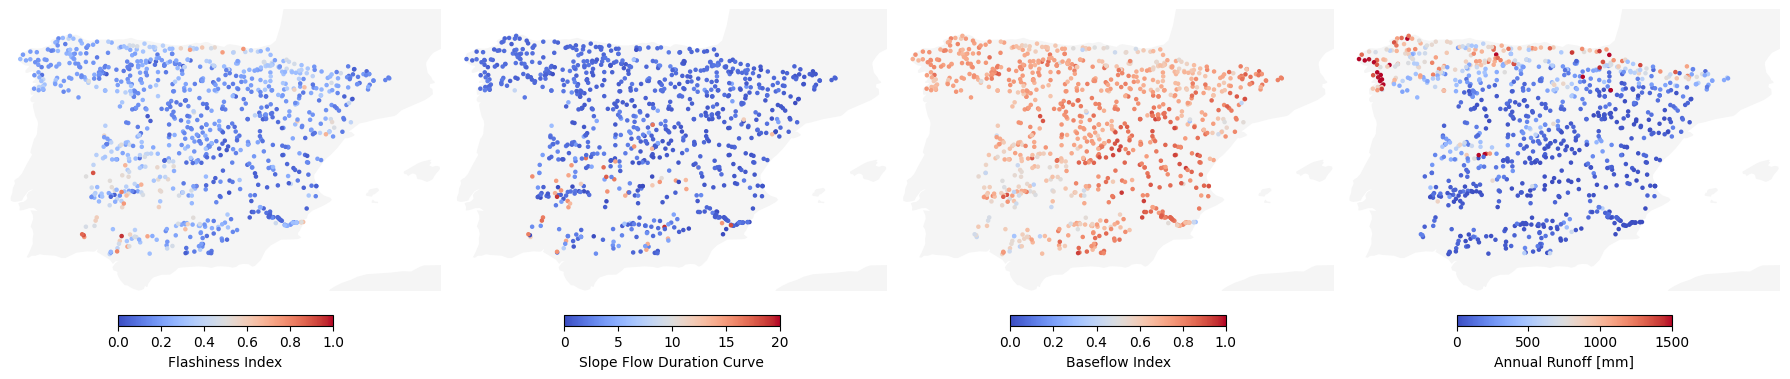

In [22]:
indices = {
    'FI': {
        'label': 'Flashiness Index',
        'vmin': 0,
        'vmax': 1
    },
    'FDC': {
        'label': 'Slope Flow Duration Curve',
        'vmin': 0,
        'vmax': 20
    },
    'BFI': {
        'label': 'Baseflow Index',
        'vmin': 0,
        'vmax': 1
    },
    'AR': {
        'label': 'Annual Runoff [mm]',
        'vmin': 0,
        'vmax': 1500
    }
}

fig, axes = plt.subplots(ncols=len(indices), figsize=(18, 5), subplot_kw={'projection': proj})
for ax, (index, attrs) in zip(axes, indices.items()):

    ax.add_feature(cf.NaturalEarthFeature('physical', 'land', '50m', edgecolor=None, facecolor='whitesmoke'), zorder=0)
    ax.set_extent([-9.5, 3.5, 36, 44.5], crs=proj)

    sct = ax.scatter(
        estaciones.geometry.x,
        estaciones.geometry.y,
        c=estaciones[index],
        s=5,
        cmap='coolwarm',
        vmin=attrs['vmin'],
        vmax=attrs['vmax']
    )
    cbar = plt.colorbar(
        sct, 
        ax=ax, 
        orientation='horizontal', 
        shrink=.5, 
        pad=.05
        )
    cbar.set_label(f'{attrs['label']}')
    ax.set_aspect('equal')
    ax.set_extent([-9.5, 3.5, 36, 44.5], crs=proj)
    ax.axis('off')

plt.tight_layout();

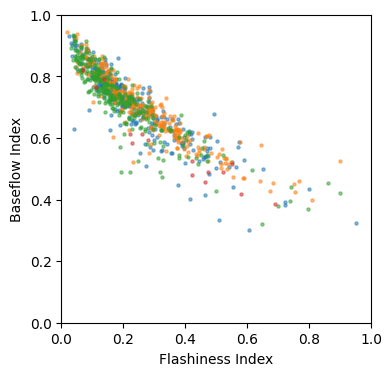

In [32]:
fig, ax = plt.subplots(figsize=(4, 4))

x = 'FI'
y = 'BFI'
for regimen, c in regimenes.items():
    mask = estaciones.REGIMEN_RIO == regimen
    ax.scatter(
        estaciones.loc[mask, x],
        estaciones.loc[mask, y],
        s=5,
        alpha=.5
    )
ax.set(
    xlabel=indices[x]['label'],
    xlim=(indices[x]['vmin'], indices[x]['vmax']),
    ylabel=indices[y]['label'],
    ylim=(indices[y]['vmin'], indices[y]['vmax']),
    );